In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Telco Customer Churn Kaggle.csv")
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [3]:
# Drop CustomerID
df.drop("CustomerID", axis=1, inplace=True)

# Check missing values
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64


In [4]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,0,68,147.58,2,0,10052.03,0
1,69,1,32,22.54,0,3,686.78,0
2,46,0,10,52.47,1,2,537.88,0
3,32,1,22,109.67,0,3,2390.04,1
4,60,0,54,130.98,0,1,7081.28,0


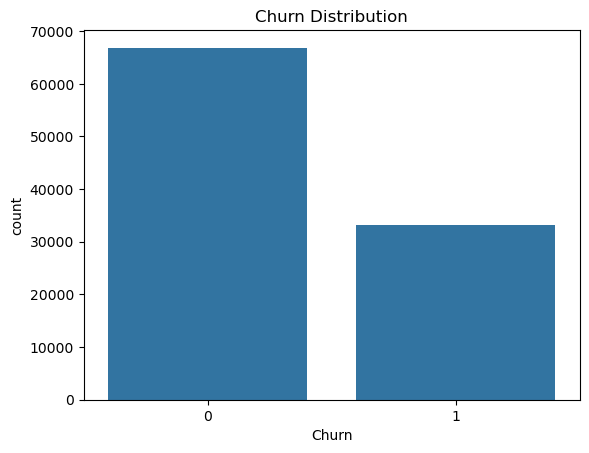

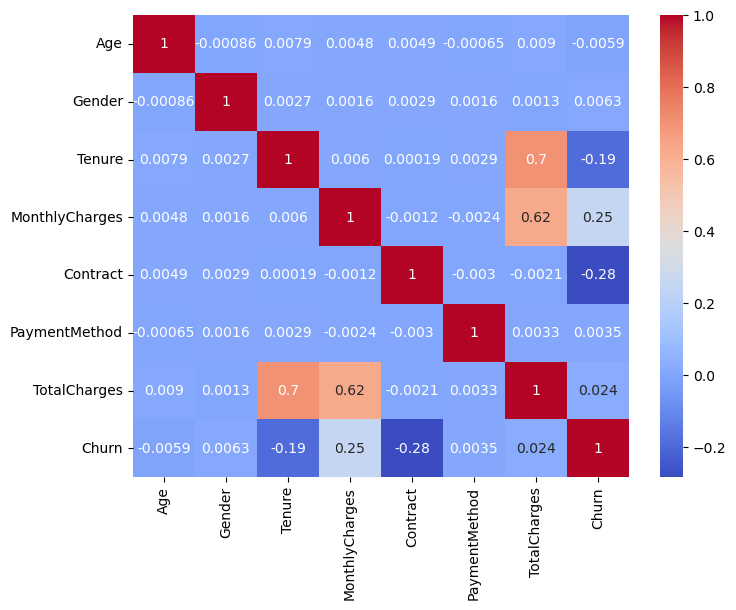

In [5]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.73525
[[11326  1968]
 [ 3327  3379]]
              precision    recall  f1-score   support

           0       0.77      0.85      0.81     13294
           1       0.63      0.50      0.56      6706

    accuracy                           0.74     20000
   macro avg       0.70      0.68      0.69     20000
weighted avg       0.73      0.74      0.73     20000



          Feature  Importance
3  MonthlyCharges    0.285658
6    TotalCharges    0.223457
2          Tenure    0.191441
0             Age    0.147280
4        Contract    0.103103
5   PaymentMethod    0.032867
1          Gender    0.016193


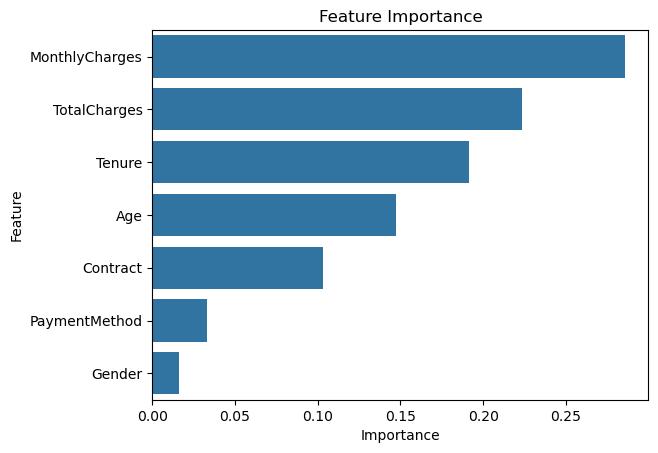

In [12]:
importances = rf.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df)

sns.barplot(x="Importance", y="Feature", data=feature_df)
plt.title("Feature Importance")
plt.show()

In [14]:
df["Prediction"] = rf.predict(X)

def segment(row):
    if row["Prediction"] == 1:
        return "At Risk"
    elif row["Tenure"] > 24:
        return "Loyal"
    else:
        return "Dormant"

df["Segment"] = df.apply(segment, axis=1)

df["Segment"].value_counts()

Segment
Loyal      49890
At Risk    31785
Dormant    18325
Name: count, dtype: int64

In [15]:
df.to_csv("final_output.csv", index=False)